> **Angepasste Version für den Methodenvergleich (CFProto).**
> Diese Kopie verwendet den **gemeinsamen Klassifikator** `resnet18_xray_224.pth`
> (torchvision-ResNet-18, trainiert in `Train_ResNet18_XRay.ipynb`, Normierung mean/std = 0.5),
> den auch alle anderen Methoden erklären. Geändert gegenüber dem Original:
> (1) Modell-Factory → torchvision-ResNet-18, (2) Checkpoint-Pfad,
> (3) Normierungskonstanten 0.485/0.229 → 0.5 (inkl. hartkodierter Stellen).
> Die Datei `resnet18_xray_224.pth` muss neben dem Notebook liegen.
> Methode/Losses/Splits/Metriken sind unverändert.

# CFProto-CFE: Chest X-Ray 

## 1. Imports & Konfiguration

In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit

torch.manual_seed(2024)
np.random.seed(2024)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Gerät:', DEVICE)

CSV_PATH   = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
BBOX_PATH  = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv'
IMAGE_GLOB = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_*/images/*.png'
PTH_PATH   = 'resnet18_xray_224.pth'   # gemeinsamer Klassifikator

IMG_SIZE      = 224
BATCH_SIZE    = 16
IMAGENET_MEAN = [0.5, 0.5, 0.5]
IMAGENET_STD  = [0.5, 0.5, 0.5]
CLASS_NAMES   = {0: 'No Finding', 1: 'Infiltration'}

print('CSV    vorhanden:', os.path.exists(CSV_PATH))
print('BBox   vorhanden:', os.path.exists(BBOX_PATH))
print('Modell vorhanden:', os.path.exists(PTH_PATH))

Gerät: cuda
CSV    vorhanden: True
BBox   vorhanden: True
Modell vorhanden: True


## 2. Datensatz laden

In [2]:
all_xray_df = pd.read_csv(CSV_PATH)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

def assign_binary_label(finding: str):
    if finding == 'No Finding':
        return 0
    elif 'Infiltration' in finding:
        return 1
    return None

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)
all_xray_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
all_xray_df['binary_label'] = all_xray_df['binary_label'].astype(int)

counts = all_xray_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Infiltration'})
print('Klassenverteilung:')
print(counts)

Klassenverteilung:
binary_label
No Finding      60361
Infiltration    19894
Name: count, dtype: int64


## 3. Bounding Boxes laden

In [3]:
bbox_df = pd.read_csv(BBOX_PATH)
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})[
    ['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]
infiltrate_bbox = bbox_df[bbox_df['Finding Label'] == 'Infiltrate'].copy()
scale = IMG_SIZE / 1024.0
for col in ['x', 'y', 'w', 'h']:
    infiltrate_bbox[col] = infiltrate_bbox[col] * scale
bbox_lookup = infiltrate_bbox.groupby('Image Index').first()[['x', 'y', 'w', 'h']].to_dict('index')
print(f'Infiltrate BBoxes: {len(bbox_lookup)} Bilder')

Infiltrate BBoxes: 123 Bilder


## 4. Train/Test Split 

In [4]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter.split(all_xray_df, groups=all_xray_df['Patient ID']))
train_df = all_xray_df.iloc[train_idx].reset_index(drop=True)
temp_df  = all_xray_df.iloc[temp_idx].reset_index(drop=True)
splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(splitter2.split(temp_df, groups=temp_df['Patient ID']))
valid_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID'])) == 0
print(f'Train: {len(train_df)}  Val: {len(valid_df)}  Test: {len(test_df)}')

Train: 56768  Val: 11926  Test: 11561


## 5. DataLoader

In [5]:
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class XRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = torch.tensor(row['binary_label'], dtype=torch.float32)
        fname = row['Image Index']
        if self.transform:
            image = self.transform(image)
        return image, label, fname

test_dataset = XRayDataset(test_df, transform=eval_transforms)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=False)

# Kleiner Trainingsdataset-Loader für CFProto Prototyp-Berechnung
train_dataset = XRayDataset(train_df.sample(n=min(2000, len(train_df)), random_state=42),
                             transform=eval_transforms)
train_loader_proto = DataLoader(train_dataset, batch_size=64, shuffle=False,
                                 num_workers=2, pin_memory=False)
print(f'Test-Batches: {len(test_loader)}')
print(f'Proto-Train Samples: {len(train_dataset)}')

Test-Batches: 723
Proto-Train Samples: 2000


## 6. Modell laden

In [6]:
from collections import OrderedDict
from functools import partial

class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_model():
    # Gemeinsamer Klassifikator: torchvision-ResNet-18 (statt Eigenbau-ResNet)
    import torchvision
    return torchvision.models.resnet18(num_classes=2)

checkpoint = torch.load(PTH_PATH, map_location=DEVICE, weights_only=False)
model      = build_model().to(DEVICE)
state      = checkpoint.get('model_state_dict', checkpoint)
model.load_state_dict(state)
model.eval()
# Feature-Encoder (bis einschl. layer4) - Ersatz fuer den Encoder-Zugriff des Eigenbau-ResNet
model_encoder = torch.nn.Sequential(model.conv1, model.bn1, model.relu, model.maxpool,
                                    model.layer1, model.layer2, model.layer3, model.layer4)
print('Modell geladen ✓')
print(f'Test-AUC:      {checkpoint.get("test_auc", "N/A")}')
print(f'Test-Accuracy: {checkpoint.get("test_accuracy", "N/A")}')
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    print('Output-Shape:', model(dummy).shape)

Modell geladen ✓
Test-AUC:      0.7513
Test-Accuracy: 0.6863
Output-Shape: torch.Size([2, 2])


## 7. Hilfsfunktionen

In [7]:
def denormalise(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

def draw_bbox_on_ax(ax, bbox_dict, image_name, color='yellow', linewidth=2):
    if image_name not in bbox_dict:
        return False
    b = bbox_dict[image_name]
    rect = patches.Rectangle(
        (b['x'], b['y']), b['w'], b['h'],
        linewidth=linewidth, edgecolor=color,
        facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)
    ax.text(b['x'], b['y'] - 4, 'GT BBox',
            color=color, fontsize=7, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.4, pad=1))
    return True

def tanh_to_img(tensor):
    """Decoder Output [-1,1] → [0,1]"""
    return (tensor + 1.0) / 2.0

print('Hilfsfunktionen definiert ✓')

Hilfsfunktionen definiert ✓


## 8. CFProto Kernfunktionen

In [ ]:
def extract_embedding(model, images):
    with torch.no_grad():
        features = model_encoder(images)          # (B, 512, 7, 7)
        emb = F.adaptive_avg_pool2d(features, (1, 1))  # (B, 512, 1, 1)
        emb = emb.view(emb.size(0), -1)            # (B, 512)
    return emb


def compute_class_prototypes(model, data_loader, device, K=20):
    model.eval()
    all_embs   = []
    all_labels = []

    print('Berechne Embeddings für Prototypen...')
    for batch_imgs, batch_lbls, _ in tqdm(data_loader, desc='Embeddings'):
        batch_imgs = batch_imgs.to(device)
        emb = extract_embedding(model, batch_imgs)
        # Modell-Vorhersage für Label 
        with torch.no_grad():
            logits = model(batch_imgs)
            preds  = logits.argmax(dim=1).cpu()
        all_embs.append(emb.cpu())
        all_labels.append(preds)

    all_embs   = torch.cat(all_embs,   dim=0)   # (N, 512)
    all_labels = torch.cat(all_labels, dim=0)   # (N,)

    prototypes = {}
    for cls in [0, 1]:
        mask     = (all_labels == cls)
        cls_embs = all_embs[mask]                # (M, 512)
        if cls_embs.size(0) == 0:
            print(f'  ⚠ Keine Embeddings für Klasse {cls}')
            continue
        # Prototyp = Mittelwert aller Klassen-Embeddings
        if K is not None and cls_embs.size(0) > K:
            # Nur die K nächsten zum Klassenmittelwert
            mean_emb = cls_embs.mean(dim=0, keepdim=True)   # (1, 512)
            dists    = torch.norm(cls_embs - mean_emb, dim=1)
            _, topk  = dists.topk(K, largest=False)
            cls_embs = cls_embs[topk]
        prototypes[cls] = cls_embs.mean(dim=0)   # (512,)
        print(f'  Prototyp Klasse {cls} ({CLASS_NAMES[cls]}): {cls_embs.size(0)} Samples')

    return prototypes, all_embs, all_labels


def find_target_prototype(source_emb, prototypes, source_class):
    best_cls  = None
    best_dist = float('inf')
    for cls, proto in prototypes.items():
        if cls == source_class:
            continue
        dist = torch.norm(source_emb - proto.to(source_emb.device)).item()
        if dist < best_dist:
            best_dist = dist
            best_cls  = cls
    return best_cls, prototypes[best_cls]


def cfproto_loss(xcf, x0, model, target_proto, source_class,
                 c=1.0, beta=0.1, theta=100.0, kappa=0.0):
    delta = xcf - x0

    # Elastic Net Regularisierung (Sparsity)
    l1_loss = delta.abs().sum()
    l2_loss = (delta ** 2).sum()

    # Prediction loss L_pred
    logits = model(xcf)
    probs  = torch.softmax(logits, dim=1)   # (B, 2)
    # Maximale Wahrscheinlichkeit einer anderen Klasse als source_class
    other_mask = torch.ones(probs.size(1), dtype=torch.bool)
    other_mask[source_class] = False
    p_source = probs[:, source_class]                        # P(original class)
    p_other  = probs[:, other_mask].max(dim=1).values        # max P(other class)
    lpred    = torch.clamp(p_source - p_other + kappa, min=-kappa).mean()

    # Prototype loss L_proto 
    features = model_encoder(xcf)                          # (B, 512, 7, 7)
    emb_xcf  = F.adaptive_avg_pool2d(features, (1, 1)).view(features.size(0), -1)  # (B, 512)
    proto    = target_proto.to(xcf.device).unsqueeze(0)    # (1, 512)
    lproto   = ((emb_xcf - proto) ** 2).sum(dim=1).mean()

    total = c * lpred + beta * l1_loss + l2_loss + theta * lproto
    return total, lpred.item(), l1_loss.item(), l2_loss.item(), lproto.item()


def compute_cfproto(
    model, images, device, prototypes,
    c=1.0, beta=0.1, theta=100.0, kappa=0.0,
    lr=0.01, max_iter=200, c_steps=5,
    feature_range=None
):
    model.eval()
    images = images.to(device)
    B      = images.size(0)

    # Feature range bestimmen (für Pixel-Clipping)
    if feature_range is None:
        # Basierend auf ImageNet-Normalisierung: ~[-2.5, 2.5] pro Kanal
        lo = torch.tensor([(0 - m) / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
                           device=device).view(1, 3, 1, 1)
        hi = torch.tensor([(1 - m) / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
                           device=device).view(1, 3, 1, 1)
    else:
        lo, hi = feature_range

    # Quellklassen & Prototypen bestimmen
    with torch.no_grad():
        logits        = model(images)
        probs_all     = torch.softmax(logits, dim=1)
        orig_probs    = probs_all[:, 1]
        source_labels = logits.argmax(dim=1)

    cfe_labels = 1 - source_labels   # Binäre Klassifikation: Ziel = andere Klasse

    xcf_batch = []

    for i in range(B):
        x0         = images[i:i+1].clone()          # (1, 3, H, W)
        src_cls    = source_labels[i].item()
        tgt_cls    = cfe_labels[i].item()
        tgt_proto  = prototypes[tgt_cls].to(device)  # (512,)

        # Initialisierung des CFE
        xcf = x0.clone().detach().requires_grad_(True)

        best_xcf    = x0.clone().detach()
        best_loss   = float('inf')
        c_current   = c

        # Äußere c-Schleife 
        for c_step in range(c_steps):
            xcf = x0.clone().detach().requires_grad_(True)
            optimizer = torch.optim.Adam([xcf], lr=lr)

            found_cf = False
            for it in range(max_iter):
                optimizer.zero_grad()

                # Feature-Range Clipping 
                with torch.no_grad():
                    xcf.clamp_(lo, hi)

                loss, lp, l1, l2, lpr = cfproto_loss(
                    xcf, x0, model, tgt_proto, src_cls,
                    c=c_current, beta=beta, theta=theta, kappa=kappa
                )
                loss.backward()
                optimizer.step()

                # Prüfen ob Vorhersage schon gewechselt hat
                with torch.no_grad():
                    pred_cf = model(xcf).argmax(dim=1).item()
                if pred_cf == tgt_cls:
                    en_loss = beta * (xcf - x0).abs().sum() + ((xcf - x0) ** 2).sum()
                    if en_loss.item() < best_loss:
                        best_loss = en_loss.item()
                        best_xcf  = xcf.clone().detach()
                    found_cf = True

            # c anpassen: falls kein CF → c erhöhen; sonst → c verringern
            if found_cf:
                c_current = c_current / 2.0
            else:
                c_current = c_current * 2.0

        xcf_batch.append(best_xcf)

    xcf_batch = torch.cat(xcf_batch, dim=0)   # (B, 3, H, W)
    return xcf_batch, cfe_labels, source_labels, orig_probs


print('CFProto Funktionen definiert ✓')

CFProto Funktionen definiert ✓


## 9. Prototypen berechnen

In [9]:
# Prototypen aus dem Trainingsset berechnen (K=20 wie im Paper)
prototypes, proto_embs, proto_labels = compute_class_prototypes(
    model, train_loader_proto, DEVICE, K=20
)

print(f'\nPrototypen berechnet:')
for cls, proto in prototypes.items():
    print(f'  Klasse {cls} ({CLASS_NAMES[cls]}): shape={proto.shape}, norm={proto.norm():.2f}')

Berechne Embeddings für Prototypen...


Embeddings: 100%|██████████| 32/32 [00:32<00:00,  1.01s/it]

  Prototyp Klasse 0 (No Finding): 20 Samples
  Prototyp Klasse 1 (Infiltration): 20 Samples

Prototypen berechnet:
  Klasse 0 (No Finding): shape=torch.Size([512]), norm=2.13
  Klasse 1 (Infiltration): shape=torch.Size([512]), norm=2.34


## 10. Sanity Check — Flip Rate

In [10]:
sample_images, sample_labels, sample_fnames = next(iter(test_loader))

xcf_batch, cfe_labels, source_labels, orig_probs = compute_cfproto(
    model, sample_images, DEVICE, prototypes,
    c=1.0, beta=0.1, theta=100.0, kappa=0.0,
    lr=0.01, max_iter=200, c_steps=5
)

with torch.no_grad():
    cf_logits = model(xcf_batch.to(DEVICE))
    cf_preds  = cf_logits.argmax(dim=1).cpu()

flip_rate = (cf_preds == cfe_labels.cpu()).float().mean()

print(f'Batch-Größe   : {len(sample_labels)}')
print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >80%)')
print(f'Quellvorhers. : {source_labels.tolist()}')
print(f'CFE-Vorhers.  : {cf_preds.tolist()}')
print(f'Zielklassen   : {cfe_labels.tolist()}')
bbox_count = sum(1 for f in sample_fnames if f in bbox_lookup)
print(f'Bilder mit BBox: {bbox_count}/{len(sample_fnames)}')
if flip_rate < 0.8:
    print('\n⚠ Flip Rate niedrig — max_iter oder c_steps erhöhen')

Batch-Größe   : 16
Flip Rate     : 100.00%  (Ziel: >80%)
Quellvorhers. : [1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0]
CFE-Vorhers.  : [0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1]
Zielklassen   : [0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1]
Bilder mit BBox: 0/16


## 11. Decoder laden (SkipDecoder für Bild-Rekonstruktion)

In [ ]:
print('CFProto: Pixelraum-Methode — kein Decoder nötig ✓')

CFProto: Pixelraum-Methode — kein Decoder nötig ✓


## 12. CFE-Bilder generieren (Decoder)

In [12]:
def get_cfe_image_from_cfproto(model, images, xcf_batch):
    """
    CFProto ist eine Pixelraum-Methode: xcf_batch IST bereits das fertige
    Counterfactual-Bild. Wir denormalisieren Original und CFE direkt — KEIN Decoder.
    Rückgabe: orig_np, cfe_np — beide (B, H, W, 3) in [0,1]
    """
    images    = images.to(DEVICE)
    xcf_batch = xcf_batch.to(DEVICE)
    orig_np = denormalise(images.cpu()).permute(0, 2, 3, 1).numpy().clip(0, 1)
    cfe_np  = denormalise(xcf_batch.detach().cpu()).permute(0, 2, 3, 1).numpy().clip(0, 1)
    return orig_np, cfe_np


print('CFE-Bildfunktion (decoder-frei) definiert ✓')

CFE-Bildfunktion (decoder-frei) definiert ✓


## 13. Visualisierung

In [ ]:
def visualise_cfproto_decoded(
    model, images, labels, fnames,
    xcf_batch, cfe_labels, source_labels, orig_probs,
    bbox_lookup, class_names,
    bbox_class_idx=1, bbox_color='yellow',
    n_samples=4, save_path='cfproto_cfe_decoded.png'
):
    """
    Drei-Panel Visualisierung pro Sample:
      Panel 1: Original xᵢ  + GT BBox (gelb, nur bei Infiltration-Bildern)
      Panel 2: CFE x'       (Decoder Output aus CFProto-perturbiertem Bild)
      Panel 3: Differenzbild |x' − xᵢ|  (hell = starke Änderung)
    """
    model.eval()
    images    = images.to(DEVICE)
    xcf_batch = xcf_batch.to(DEVICE)
    n         = min(n_samples, images.size(0))

    orig_np, cfe_np = get_cfe_image_from_cfproto(model, images[:n], xcf_batch[:n])

    with torch.no_grad():
        cf_logits  = model(xcf_batch[:n].to(DEVICE))
        cfe_preds  = cf_logits.argmax(dim=1).cpu()
        cfe_probs_val = torch.softmax(cf_logits, dim=1)[:, 1].cpu().numpy()

    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(13, n * 4.5))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Original xᵢ + GT BBox', "CFE x' (Pixelraum)", "|x' − xᵢ| Differenz"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=10)

    for i in range(n):
        o_np     = orig_np[i]
        c_np     = cfe_np[i]
        diff_np  = np.abs(c_np - o_np).mean(axis=2)
        diff_np  = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)

        src_lbl  = source_labels[i].item()
        cfe_lbl  = cfe_labels[i].item()
        true_lbl = int(labels[i])
        fname    = fnames[i]
        flipped  = int(cfe_probs_val[i] >= 0.5) == cfe_lbl
        has_bbox = fname in bbox_lookup

        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'

        ax1 = axes[i, 0]
        ax1.imshow(o_np)
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax1, bbox_lookup, fname, color=bbox_color)
        elif true_lbl == bbox_class_idx:
            ax1.text(5, IMG_SIZE - 8, 'Keine BBox verfügbar',
                     color='orange', fontsize=6,
                     bbox=dict(facecolor='black', alpha=0.5, pad=1))
        ax1.set_ylabel(
            f'Sample {i+1}\n'
            f'{class_names[src_lbl]} → {class_names[cfe_lbl]}\n'
            f'Wahr: {class_names[true_lbl]}',
            fontsize=9, color=pred_col, rotation=0,
            labelpad=110, va='center', fontweight='bold'
        )
        ax1.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax1.set_xlabel(
            f'Pred: {class_names[src_lbl]} ({orig_probs_np[i]:.1%})',
            fontsize=9, color=pred_col
        )
        ax1.axis('off')

        ax2 = axes[i, 1]
        ax2.imshow(c_np)
        for spine in ax2.spines.values():
            spine.set_edgecolor(flip_col)
            spine.set_linewidth(4)
        ax2.set_visible(True)
        ax2.text(0.5, 0.05, flip_txt,
                 transform=ax2.transAxes,
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='white',
                 bbox=dict(facecolor=flip_col, alpha=0.85, pad=3))
        ax2.set_xlabel(
            f'Ziel: {class_names[cfe_lbl]} ({cfe_probs_val[i]:.1%})',
            fontsize=9, color=flip_col, fontweight='bold'
        )
        ax2.tick_params(left=False, bottom=False, labelleft=False, labelbottom=True)

        
        ax3 = axes[i, 2]
        im  = ax3.imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax3, bbox_lookup, fname, color='cyan', linewidth=1)
        ax3.axis('off')

    plt.suptitle(
        "CFProto-CFE + Decoder: Original xᵢ  |  CFE x'  |  Differenz |x' − xᵢ|\n"
        "Gelb = GT BBox (Infiltration)  |  Cyan = BBox auf Differenz  |  "
        "Grün = Vorhersage gekippt  |  Rot = nicht gekippt",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert → {save_path}')

print('Visualisierungsfunktion definiert ✓')

Visualisierungsfunktion definiert ✓


## 14. Visualisierung mit Random Test-Batch

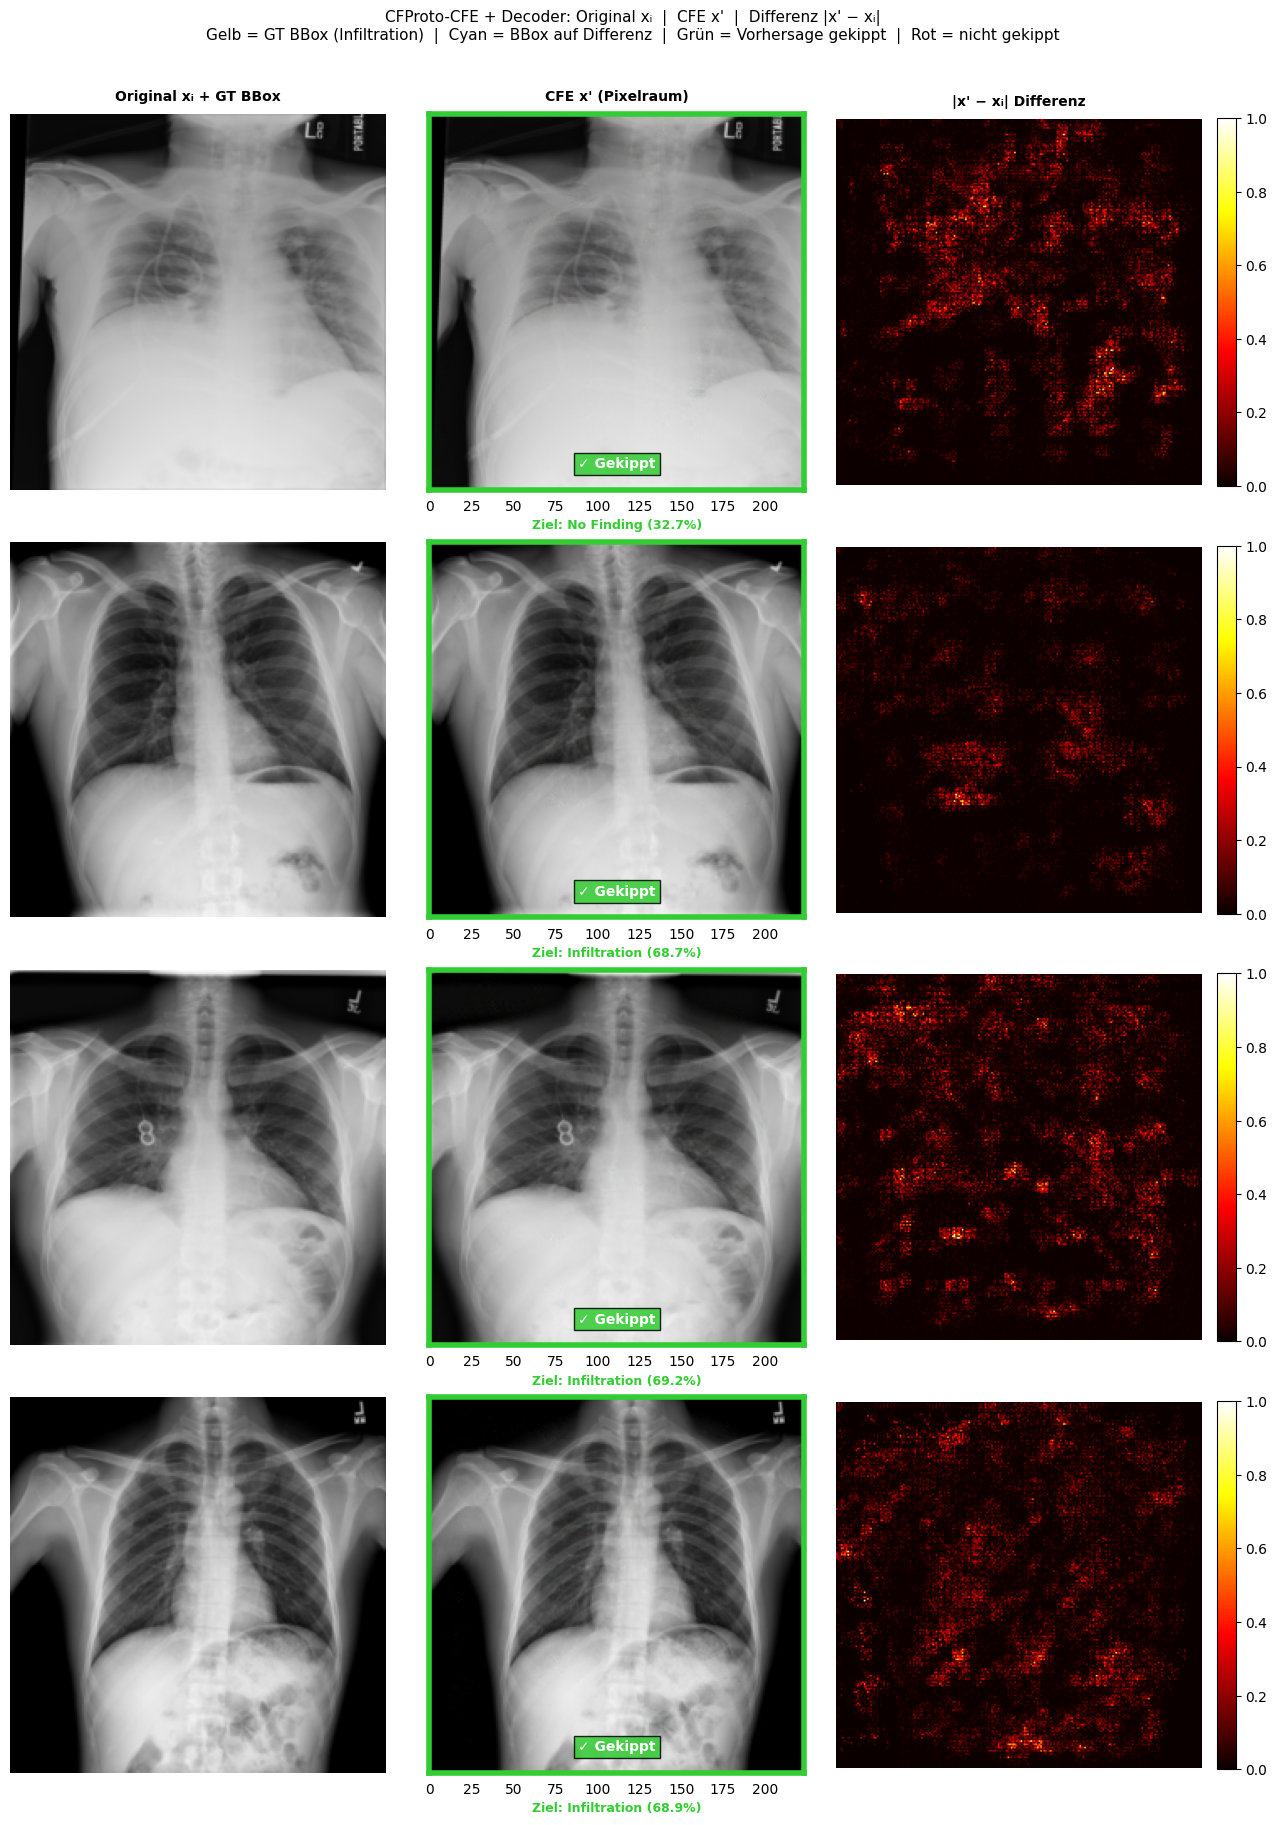

Gespeichert → /kaggle/working/cfproto_cfe_xray.png


In [14]:
# Random Test-Batch
sample_images, sample_labels, sample_fnames = next(iter(test_loader))

xcf_b, cfe_b, src_b, prob_b = compute_cfproto(
    model, sample_images, DEVICE, prototypes,
    c=1.0, beta=0.1, theta=100.0, kappa=0.0,
    lr=0.01, max_iter=200, c_steps=5
)

visualise_cfproto_decoded(
    model         = model,
    images        = sample_images,
    labels        = sample_labels,
    fnames        = sample_fnames,
    xcf_batch     = xcf_b,
    cfe_labels    = cfe_b,
    source_labels = src_b,
    orig_probs    = prob_b,
    bbox_lookup   = bbox_lookup,
    class_names   = CLASS_NAMES,
    bbox_class_idx = 1,
    bbox_color    = 'yellow',
    n_samples     = 4,
    save_path     = '/kaggle/working/cfproto_cfe_xray.png'
)

## 15. Visualisierung mit BBox-Bildern (Infiltration)

Infiltration-Bilder mit BBox im Test-Set: 11


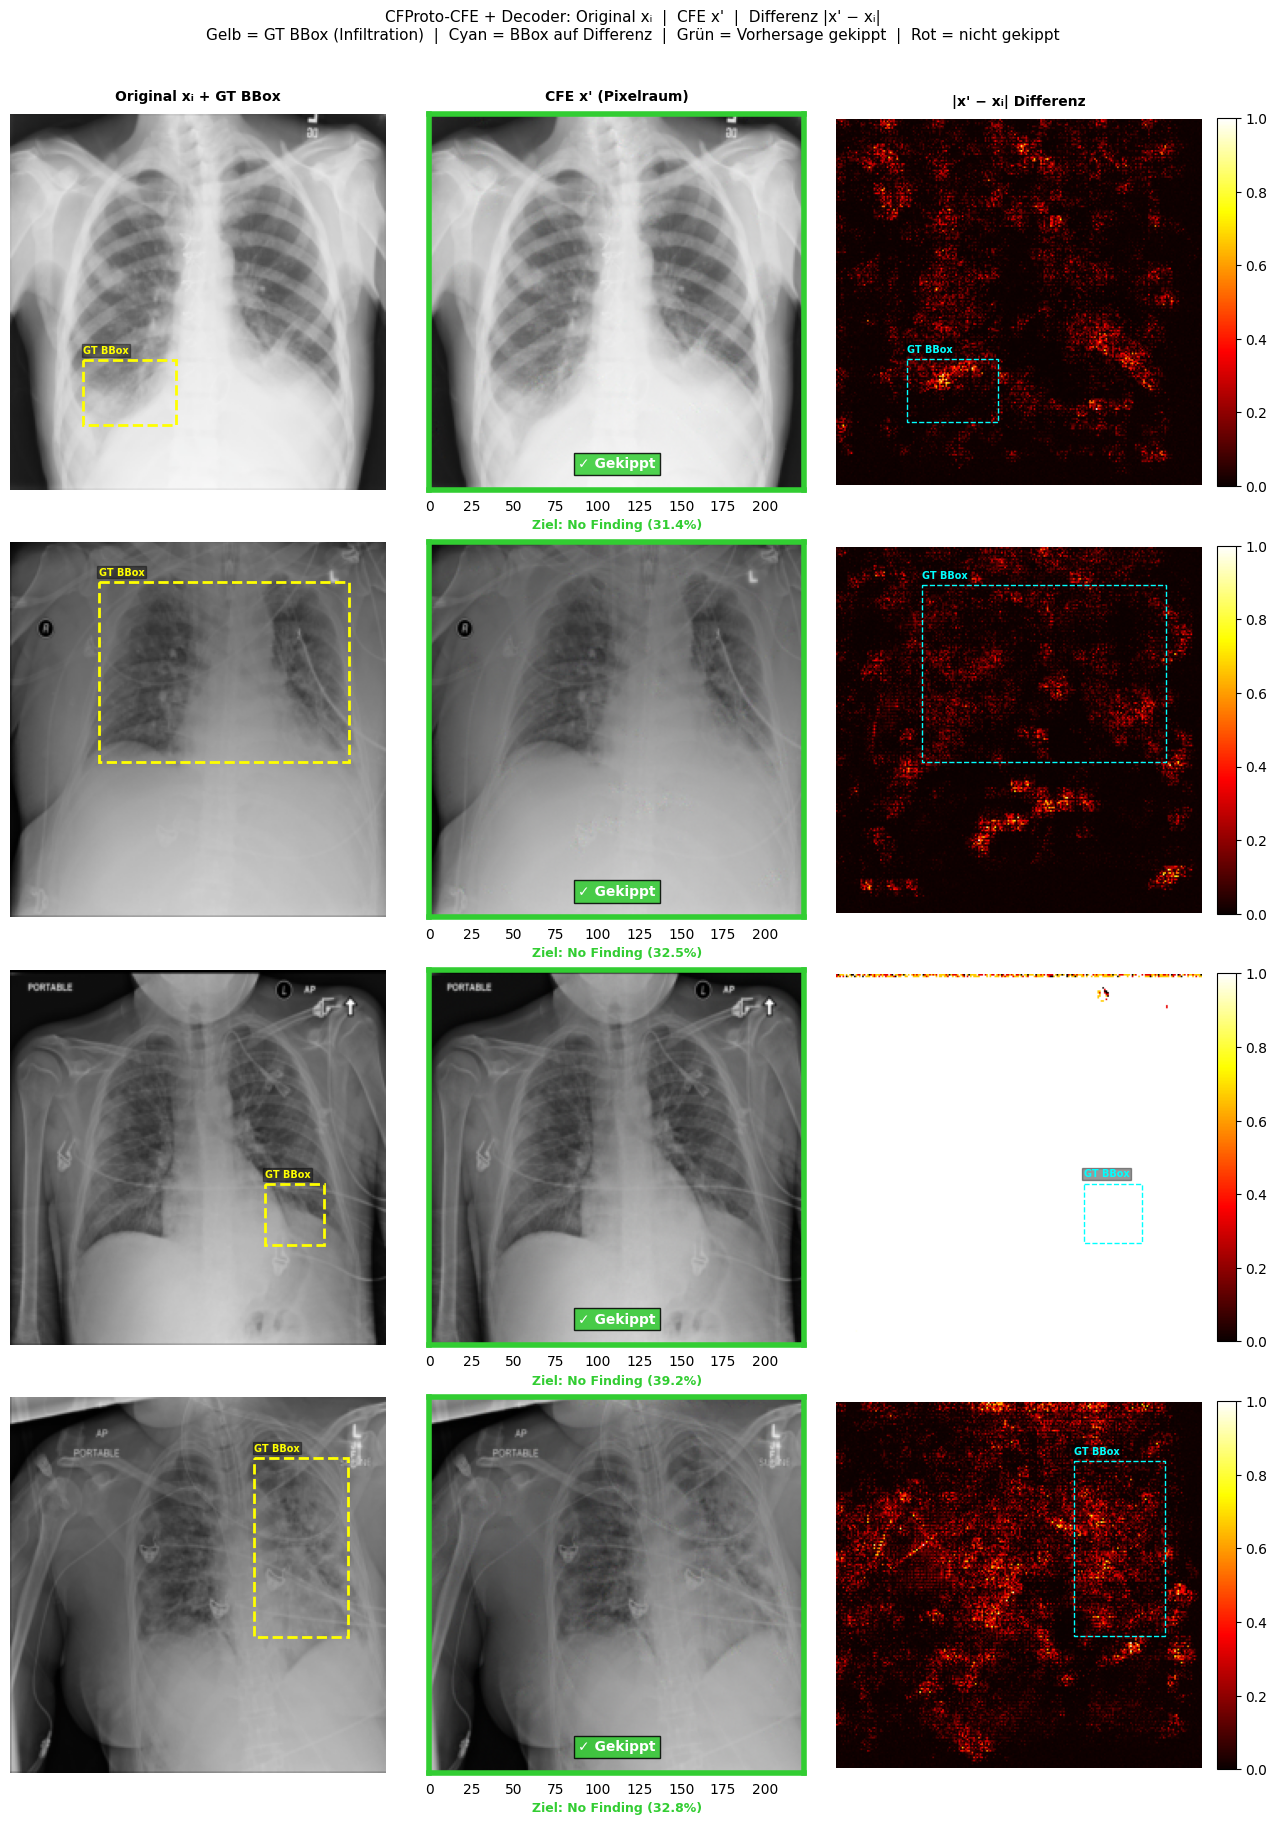

Gespeichert → /kaggle/working/cfproto_cfe_xray_bbox.png


In [15]:
bbox_image_names = set(bbox_lookup.keys())
test_with_bbox = test_df[
    (test_df['binary_label'] == 1) &
    (test_df['Image Index'].isin(bbox_image_names))
].reset_index(drop=True)

print(f'Infiltration-Bilder mit BBox im Test-Set: {len(test_with_bbox)}')

if len(test_with_bbox) == 0:
    test_with_bbox = all_xray_df[
        (all_xray_df['binary_label'] == 1) &
        (all_xray_df['Image Index'].isin(bbox_image_names))
    ].reset_index(drop=True)
    print(f'Verwende alle verfügbaren BBox-Bilder: {len(test_with_bbox)}')

bbox_dataset = XRayDataset(test_with_bbox, transform=eval_transforms)
bbox_loader  = DataLoader(bbox_dataset, batch_size=8, shuffle=True,
                          num_workers=2, pin_memory=False)
bbox_imgs, bbox_lbls, bbox_fnames = next(iter(bbox_loader))

xcf_b_bbox, cfe_b_bbox, src_b_bbox, prob_b_bbox = compute_cfproto(
    model, bbox_imgs, DEVICE, prototypes,
    c=1.0, beta=0.1, theta=100.0, kappa=0.0,
    lr=0.01, max_iter=200, c_steps=5
)

visualise_cfproto_decoded(
    model         = model,
    images        = bbox_imgs,
    labels        = bbox_lbls,
    fnames        = bbox_fnames,
    xcf_batch     = xcf_b_bbox,
    cfe_labels    = cfe_b_bbox,
    source_labels = src_b_bbox,
    orig_probs    = prob_b_bbox,
    bbox_lookup   = bbox_lookup,
    class_names   = CLASS_NAMES,
    bbox_class_idx = 1,
    bbox_color    = 'yellow',
    n_samples     = 4,
    save_path     = '/kaggle/working/cfproto_cfe_xray_bbox.png'
)

## 16. Batch-Evaluation (Flip Rate)

In [16]:
n_batches    = 10
total_flip   = 0
total_images = 0

for batch_imgs, batch_lbls, batch_fnames in tqdm(
        list(test_loader)[:n_batches], desc='CFE Evaluation'):
    xcf, c_lbls, s_lbls, o_probs = compute_cfproto(
        model, batch_imgs, DEVICE, prototypes,
        c=1.0, beta=0.1, theta=100.0, kappa=0.0,
        lr=0.01, max_iter=200, c_steps=5
    )
    with torch.no_grad():
        preds = model(xcf.to(DEVICE)).argmax(dim=1).cpu()
    total_flip   += (preds == c_lbls.cpu()).sum().item()
    total_images += len(batch_lbls)

print(f'\nFlip Rate: {total_flip}/{total_images} = {total_flip/total_images:.2%}')

CFE Evaluation: 100%|██████████| 10/10 [48:39<00:00, 291.94s/it]


Flip Rate: 160/160 = 100.00%


## 17. Metriken installieren & definieren

In [17]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 70.6 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.

In [ ]:
import time
from scipy import linalg as scipy_linalg

# LPIPS
try:
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(DEVICE)
    lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print('LPIPS geladen ✓')
except ImportError:
    LPIPS_AVAILABLE = False
    print('⚠ lpips nicht verfügbar — pip install lpips')


# L1
def compute_l1(orig_np, cfe_np):
    """
    L1-Norm nach Wachter et al. (2017).
    Niedrigerer Wert = CF liegt näher am Original.
    """
    diffs = np.abs(orig_np - cfe_np)             # (B, H, W, 3)
    l1_per_sample = diffs.sum(axis=(1,2,3)) / (orig_np.shape[1] * orig_np.shape[2] * orig_np.shape[3])
    return float(l1_per_sample.mean())


# Sparsity
def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    """
    Anteil der veränderten Pixel nach Moreira et al. (2025).
    Niedrigerer Wert = weniger Pixel verändert = interpretierbarer.
    """
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)   # (B, H, W)
    changed = (diff > threshold).astype(float)
    sparsity_per_sample = changed.mean(axis=(1,2))
    return float(sparsity_per_sample.mean())


# LPIPS
def compute_lpips(orig_np, cfe_np):
    """
    Learned Perceptual Image Patch Similarity nach Zhang et al. (2018).
    Verwendet SqueezeNet wie in Chowdhury et al. (2025).
    Niedrigerer Wert = wahrnehmbar ähnlicher.
    """
    if not LPIPS_AVAILABLE:
        return None
    orig_t = torch.tensor(orig_np, dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    cfe_t  = torch.tensor(cfe_np,  dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    with torch.no_grad():
        scores = lpips_fn(orig_t, cfe_t)
    return float(scores.mean().cpu())


# FID
from torchvision.models import inception_v3

@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    """
    Extrahiert 2048-dim InceptionV3 Features für FID.
    imgs_np: (B, H, W, 3) in [0,1]
    """
    if not hasattr(extract_inception_features, '_model'):
        model_inc = inception_v3(weights='DEFAULT', transform_input=False)
        model_inc.fc = nn.Identity()
        model_inc = model_inc.eval().to(DEVICE)
        extract_inception_features._model = model_inc

    inc   = extract_inception_features._model
    feats = []
    for i in range(0, len(imgs_np), batch_size):
        batch = imgs_np[i:i+batch_size]
        t = torch.tensor(batch, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)
        t = torch.nn.functional.interpolate(t, size=(299,299), mode='bilinear',
                                             align_corners=False)
        feat = inc(t)
        feats.append(feat.cpu().numpy())
    return np.concatenate(feats, axis=0)


def compute_fid(real_np, fake_np):
    """
    FID über InceptionV3 Features (2048-dim).
    Niedrigerer Wert = generierte CFs ähneln echter Bildverteilung.
    """
    real_feats = extract_inception_features(real_np)
    fake_feats = extract_inception_features(fake_np)

    mu_r  = real_feats.mean(axis=0)
    mu_f  = fake_feats.mean(axis=0)
    sig_r = np.cov(real_feats, rowvar=False)
    sig_f = np.cov(fake_feats, rowvar=False)

    diff     = mu_r - mu_f
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))
    return fid


# EBPG
def compute_ebpg(orig_np, cfe_np, bboxes_pixel):
    """
    Energy-Based Pointing Game nach Wang et al. (2019).
    EBPG = Energie im BBox-Bereich / Gesamtenergie des Differenzbildes.
    Höherer Wert = Änderungen konzentrieren sich auf die annotierte Region.
    """
    scores = []
    for i, bbox in enumerate(bboxes_pixel):
        diff = np.abs(cfe_np[i] - orig_np[i]).mean(axis=-1)
        total_energy = diff.sum() + 1e-8
        x1 = max(0, int(bbox['x']))
        y1 = max(0, int(bbox['y']))
        x2 = min(224, int(bbox['x'] + bbox['w']))
        y2 = min(224, int(bbox['y'] + bbox['h']))
        bbox_energy = diff[y1:y2, x1:x2].sum()
        scores.append(bbox_energy / total_energy)
    return float(np.mean(scores)) if scores else None


# Validity / Denoised Validity
def compute_validity(model, cfe_imgs_tensor, cfe_labels, denoise_sigma=None):
    """
    Validity nach Verma et al. (2022).
    Prüft ob das dekodierte CFE-Bild (nach Re-Normalisierung) als Zielklasse klassifiziert wird.
    denoise_sigma: wenn gesetzt → Denoised Validity (Gaussian Blur vor Klassifikation).
    """
    from torchvision.transforms.functional import gaussian_blur

    model.eval()
    cfe_imgs_tensor = cfe_imgs_tensor.to(DEVICE)

    if denoise_sigma is not None:
        kernel_size = int(denoise_sigma * 6) | 1
        kernel_size = max(kernel_size, 3)
        cfe_blurred = gaussian_blur(cfe_imgs_tensor, kernel_size=[kernel_size, kernel_size],
                                    sigma=[denoise_sigma, denoise_sigma])
    else:
        cfe_blurred = cfe_imgs_tensor

    # CFE-Bilder in [0,1]
    mean = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1,3,1,1)
    std  = torch.tensor(IMAGENET_STD,  device=DEVICE).view(1,3,1,1)
    cfe_norm = (cfe_blurred - mean) / std

    with torch.no_grad():
        logits = model(cfe_norm)
        preds  = logits.argmax(dim=1).cpu()

    validity = (preds == cfe_labels.cpu()).float().mean()
    return float(validity)


# Coverage
def compute_coverage(model, images, prototypes, n_runs=5):
    """
    Coverage nach Moreira et al. (2025): wie oft findet der Algorithmus
    ein valides CF? Gemittelt über n_runs Durchläufe.
    """
    images = images.to(DEVICE)
    valid_runs = []

    for run in range(n_runs):
        torch.manual_seed(run)
        xcf, c_lbls, s_lbls, o_probs = compute_cfproto(
            model, images, DEVICE, prototypes,
            c=1.0, beta=0.1, theta=100.0, kappa=0.0,
            lr=0.01, max_iter=200, c_steps=5
        )
        with torch.no_grad():
            preds = model(xcf.to(DEVICE)).argmax(dim=1).cpu()
        rate  = (preds == c_lbls.cpu()).float().mean().item()
        valid_runs.append(rate)

    return float(np.mean(valid_runs)), float(np.std(valid_runs))


print('Metrik-Funktionen definiert ✓')

Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 4.73M/4.73M [00:00<00:00, 64.4MB/s]

Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/squeeze.pth
LPIPS geladen ✓
Metrik-Funktionen definiert ✓


## 18. Metriken berechnen

In [ ]:

EVAL_SEED     = 42
N_EVAL_IMAGES = 80
TARGET_CLASS  = 1   # Zielklasse mit BBoxen

_idx_all  = list(range(len(test_df)))
_idx_bbox = [i for i in _idx_all
             if int(test_df.iloc[i]['binary_label']) == TARGET_CLASS
             and test_df.iloc[i]['Image Index'] in bbox_lookup]
_idx_rest = [i for i in _idx_all if i not in set(_idx_bbox)]

_rng = np.random.RandomState(EVAL_SEED)
_rng.shuffle(_idx_bbox)
_rng.shuffle(_idx_rest)

_n_bbox = min(len(_idx_bbox), N_EVAL_IMAGES // 2)
_sel    = _idx_bbox[:_n_bbox] + _idx_rest[:(N_EVAL_IMAGES - _n_bbox)]
_rng2   = np.random.RandomState(EVAL_SEED)
_rng2.shuffle(_sel)
eval_indices = _sel[:N_EVAL_IMAGES]

eval_df      = test_df.iloc[eval_indices].reset_index(drop=True)
eval_dataset = XRayDataset(eval_df, transform=eval_transforms)
eval_loader  = DataLoader(eval_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=False)

_n_tgt = int((eval_df['binary_label'] == TARGET_CLASS).sum())
_n_bbx = sum(1 for _, r in eval_df.iterrows()
             if r['Image Index'] in bbox_lookup and int(r['binary_label']) == TARGET_CLASS)
print(f'Fester Eval-Satz: {len(eval_df)} Bilder (Seed {EVAL_SEED})')
print(f'  Zielklasse:        {_n_tgt}')
print(f'  davon mit BBox:    {_n_bbx}  → EBPG-Stichprobe')


Fester Eval-Satz: 80 Bilder (Seed 42)
  Zielklasse:        25
  davon mit BBox:    11  → EBPG-Stichprobe


In [ ]:


N_EVAL_BATCHES = 5
DENOISE_SIGMA  = 1.0

all_l1, all_sparsity, all_lpips = [], [], []
all_real_np, all_cfe_np = [], []
all_cfe_tensor, all_cfe_labels = [], []
all_ebpg = []
all_eval_imgs = []          # für Coverage über den vollen Eval-Satz
total_time = 0.0
n_images   = 0

print(f'Berechne Metriken über {len(eval_dataset)} Bilder (fester Eval-Satz)...')
print('-' * 60)

for batch_imgs, batch_lbls, batch_fnames in tqdm(
        eval_loader, desc='Metrik-Evaluation'):

    t0 = time.time()
    xcf, c_lbls, s_lbls, o_probs = compute_cfproto(
        model, batch_imgs, DEVICE, prototypes,
        c=1.0, beta=0.1, theta=100.0, kappa=0.0,
        lr=0.01, max_iter=200, c_steps=5
    )
    total_time += time.time() - t0
    n_images   += len(batch_lbls)

    
    orig_np = denormalise(batch_imgs.cpu()).permute(0, 2, 3, 1).numpy()
    cfe_np  = denormalise(xcf.detach().cpu()).permute(0, 2, 3, 1).numpy().clip(0, 1)

    all_l1.append(compute_l1(orig_np, cfe_np))
    all_sparsity.append(compute_sparsity_rate(orig_np, cfe_np))

    if LPIPS_AVAILABLE:
        all_lpips.append(compute_lpips(orig_np, cfe_np))

    all_real_np.append(orig_np)
    all_cfe_np.append(cfe_np)
    all_eval_imgs.append(batch_imgs.cpu())

    # Validity-Tensoren: CF-Bild in [0,1] (compute_validity re-normalisiert selbst)
    cfe_t = torch.tensor(cfe_np, dtype=torch.float32).permute(0, 3, 1, 2)
    all_cfe_tensor.append(cfe_t)
    all_cfe_labels.append(c_lbls.cpu())

    # EBPG — nur für BBox-Bilder der Zielklasse
    batch_bboxes = []
    batch_valid  = []
    for i, fname in enumerate(batch_fnames):
        if fname in bbox_lookup and int(batch_lbls[i]) == 1:
            batch_bboxes.append(bbox_lookup[fname])
            batch_valid.append(i)
    if batch_bboxes:
        ebpg = compute_ebpg(orig_np[batch_valid], cfe_np[batch_valid], batch_bboxes)
        if ebpg is not None:
            all_ebpg.append(ebpg)

# FID
real_all  = np.concatenate(all_real_np, axis=0)
cfe_all   = np.concatenate(all_cfe_np,  axis=0)
fid_score = compute_fid(real_all, cfe_all)

# Validity
all_cfe_tensor_cat = torch.cat(all_cfe_tensor, dim=0)
all_cfe_labels_cat = torch.cat(all_cfe_labels, dim=0)

validity          = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat)
denoised_validity = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat,
                                     denoise_sigma=DENOISE_SIGMA)

# Coverage
print('Berechne Coverage (5 Runs über den festen Eval-Satz)...')
eval_imgs_cat = torch.cat(all_eval_imgs, dim=0)
coverage_mean, coverage_std = compute_coverage(
    model, eval_imgs_cat, prototypes, n_runs=5
)

# Efficiency
efficiency = total_time / n_images

print('\n' + '═' * 60)
print('METRIK-ERGEBNISSE — CFProto-CFE Chest X-Ray')
print('═' * 60)
print(f'\n── Proximity ───────────────────────────────────────────')
print(f'  L1-Distanz:           {np.mean(all_l1):.4f}  (↓ besser)')

print(f'\n── Interpretierbarkeit ─────────────────────────────────')
print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}  (↓ besser)')
if LPIPS_AVAILABLE:
    print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}  (↓ besser)')
else:
    print(f'  LPIPS:                nicht verfügbar')

print(f'\n── Plausibilität ───────────────────────────────────────')
print(f'  FID:                  {fid_score:.2f}   (↓ besser)')

if all_ebpg:
    print(f'\n── Lokalisierung (BBox-Bilder) ─────────────────────────')
    print(f'  EBPG:                 {np.mean(all_ebpg):.4f}  (↑ besser)')
    print(f'  Anzahl BBox-Samples (Batches): {len(all_ebpg)}')

print(f'\n── Funktionalität ──────────────────────────────────────')
print(f'  Validity:             {validity:.2%}  (↑ besser)')
print(f'  Denoised Validity:    {denoised_validity:.2%}  (↑ besser, σ={DENOISE_SIGMA})')
print(f'  Δ Validity:           {validity - denoised_validity:.2%}  (↓ besser = weniger adversarial)')
print(f'  Coverage:             {coverage_mean:.2%} ± {coverage_std:.2%}  (↑ besser)')
print(f'  Efficiency:           {efficiency:.3f}s / CF  (↓ besser)')
print('═' * 60)

Berechne Metriken über 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 5/5 [24:49<00:00, 297.82s/it]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 159MB/s] 
/tmp/ipykernel_23/765520412.py:99: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)


Berechne Coverage (5 Runs über den festen Eval-Satz)...

════════════════════════════════════════════════════════════
METRIK-ERGEBNISSE — CFProto-CFE Chest X-Ray
════════════════════════════════════════════════════════════

── Proximity ───────────────────────────────────────────
  L1-Distanz:           0.0016  (↓ besser)

── Interpretierbarkeit ─────────────────────────────────
  Sparsity Rate:        0.9231  (↓ besser)
  LPIPS (SqueezeNet):   0.0115  (↓ besser)

── Plausibilität ───────────────────────────────────────
  FID:                  5.33   (↓ besser)

── Lokalisierung (BBox-Bilder) ─────────────────────────
  EBPG:                 0.1224  (↑ besser)
  Anzahl BBox-Samples (Batches): 4

── Funktionalität ──────────────────────────────────────
  Validity:             100.00%  (↑ besser)
  Denoised Validity:    12.50%  (↑ besser, σ=1.0)
  Δ Validity:           87.50%  (↓ besser = weniger adversarial)
  Coverage:             100.00% ± 0.00%  (↑ besser)
  Efficiency:           18.